In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/f1_features.csv')
print(f"✅ Loaded: {df.shape}")
df.head()

✅ Loaded: (25898, 15)


,grid,quali_position,driver_rolling_avg_finish,constructor_rolling_avg_finish,driver_circuit_avg_finish,prev_standing,pit_stop_count,is_wet_race,precipitation_mm,year,round,driverId,constructorId,circuitId,positionOrder
0,1,1.0,6.6,6.6,3.0,5.0,0.0,0,0.0,2008,1,1,1,1,1
1,18,15.0,5.6,5.6,2.0,NaN,0.0,0,0.0,2009,1,1,1,1,20
2,11,11.0,5.8,5.8,8.0,3.0,0.0,1,3.7,2010,2,1,1,1,6
3,2,2.0,6.4,6.4,7.5,4.0,2.0,0,0.0,2011,1,1,1,1,2
4,1,1.0,7.4,7.4,6.4,5.0,2.0,0,0.0,2012,1,1,1,1,3


In [29]:
le = LabelEncoder()
for col in ['driverId', 'constructorId', 'circuitId']:
    df[col] = le.fit_transform(df[col].astype(str))

fill_cols = ['quali_position', 'driver_circuit_avg_finish',
             'prev_standing', 'pit_stop_count']
for col in fill_cols:
    df[col] = df[col].fillna(df[col].median())

df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(df.median(numeric_only=True))

print("✅ Encoded & filled!")
print(f"Any NaNs? {df.isnull().sum().sum()}")

✅ Encoded & filled!
Any NaNs? 0


In [30]:
X = df.drop(columns=['positionOrder'])
y = df['positionOrder']

# Time-based split — train on ≤2021, test on 2022+
train_mask = df['year'] <= 2021
test_mask  = df['year'] >  2021

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"✅ Train: {X_train.shape}  |  Test: {X_test.shape}")

✅ Train: (24547, 14)  |  Test: (1351, 14)


In [31]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

mae  = mean_absolute_error(y_test, lr_preds)
rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
r2   = r2_score(y_test, lr_preds)

print("📊 Linear Regression:")
print(f"   MAE:  {mae:.3f}  (avg positions off)")
print(f"   RMSE: {rmse:.3f}")
print(f"   R²:   {r2:.3f}")

📊 Linear Regression:
   MAE:  3.267  (avg positions off)
   RMSE: 4.280
   R²:   0.450


In [32]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

mae  = mean_absolute_error(y_test, rf_preds)
rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
r2   = r2_score(y_test, rf_preds)

print("📊 Random Forest:")
print(f"   MAE:  {mae:.3f}")
print(f"   RMSE: {rmse:.3f}")
print(f"   R²:   {r2:.3f}")

📊 Random Forest:
   MAE:  3.186
   RMSE: 4.067
   R²:   0.503


In [33]:
xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=50)
xgb_preds = xgb.predict(X_test)

mae  = mean_absolute_error(y_test, xgb_preds)
rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
r2   = r2_score(y_test, xgb_preds)

print("\n📊 XGBoost:")
print(f"   MAE:  {mae:.3f}")
print(f"   RMSE: {rmse:.3f}")
print(f"   R²:   {r2:.3f}")

[0]	validation_0-rmse:6.03910
[50]	validation_0-rmse:3.99565
[100]	validation_0-rmse:3.89071
[150]	validation_0-rmse:3.85767
[200]	validation_0-rmse:3.85844
[250]	validation_0-rmse:3.88385
[299]	validation_0-rmse:3.89175

📊 XGBoost:
   MAE:  2.959
   RMSE: 3.892
   R²:   0.545


            Model      MAE     RMSE       R2
Linear Regression 3.267189 4.280267 0.449891
    Random Forest 3.185665 4.066595 0.503443
          XGBoost 2.959368 3.891749 0.545225


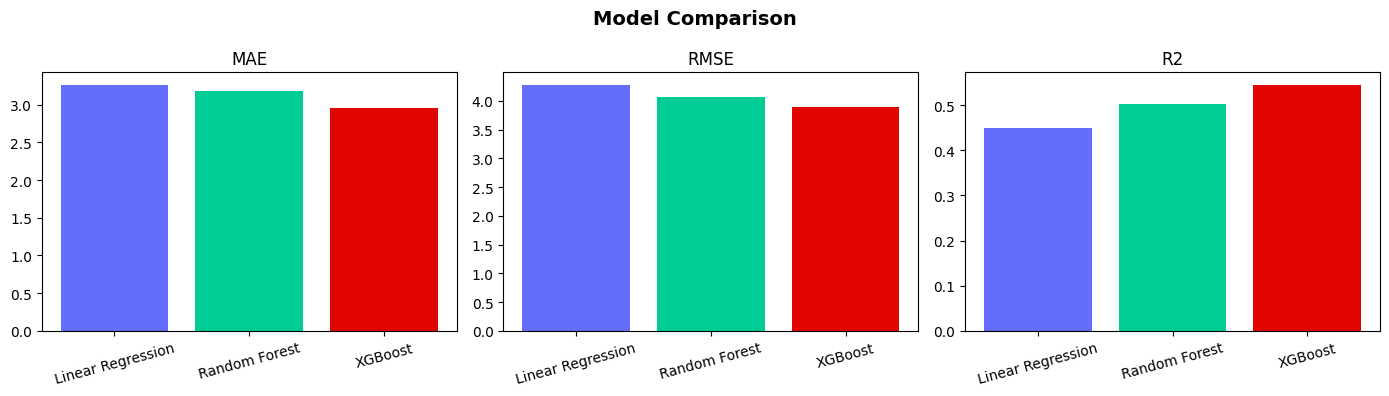

In [34]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE':   [
        mean_absolute_error(y_test, lr_preds),
        mean_absolute_error(y_test, rf_preds),
        mean_absolute_error(y_test, xgb_preds)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, lr_preds)),
        np.sqrt(mean_squared_error(y_test, rf_preds)),
        np.sqrt(mean_squared_error(y_test, xgb_preds))
    ],
    'R2': [
        r2_score(y_test, lr_preds),
        r2_score(y_test, rf_preds),
        r2_score(y_test, xgb_preds)
    ]
})

print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    colors = ['#636EFA', '#00CC96', '#e10600']
    ax.bar(comparison['Model'], comparison[metric], color=colors)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

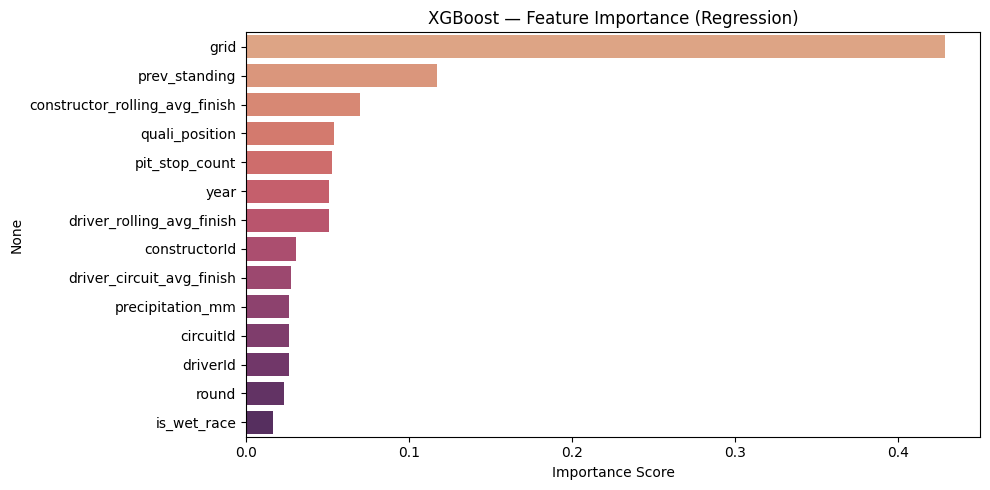

In [35]:
feat_imp = pd.Series(xgb.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='flare')
plt.title('XGBoost — Feature Importance (Regression)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [36]:
joblib.dump(lr,  '../models/linear_regression.pkl')
joblib.dump(rf,  '../models/random_forest.pkl')
joblib.dump(xgb, '../models/xgboost.pkl')

print("✅ All 3 regression models saved!")

✅ All 3 regression models saved!
